# Chapter 10 Solutions: Quantum Phase Estimation

---

**📘 INSTRUCTOR NOTE:**
- Solutions use the same utilities as the main textbook notebooks
- Students should work through the main chapter notebook first
- Some solutions may still be in development (marked as WIP)

---


In [7]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from itertools import cycle
from scipy.sparse import diags
# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent ))

# Import shared utilities (same as main notebooks)
from Chapter05_QuantumGates_functions import simulateCircuit
from Chapter10_QPE_functions import myQPESingleBit, myQPEMultiBit

In [8]:

lines = ["-","--","-.",":"]
linecycler = cycle(lines)

## Choose Example

In [9]:
example = 1
if (example == 1):
	A = np.array([[1,0],[0,0.75]])
	v0 = np.array([0,1])
	v1 = np.array([1,0])
	D = [0.75,1]
	a = [1/np.sqrt(2),1/np.sqrt(2)]
	a= [1,0]
	v = a[0]*v0 + a[1]*v1
	lambdaUpper = 2
	m = 3
elif (example == 2):
	A = np.array([[2,-1],[-1,2]])
	v0 = np.array([1/np.sqrt(2),1/np.sqrt(2)])
	v1 = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
	D = [1,3]
	a = [1,0]
	v = a[0]*v0 + a[1]*v1
	lambdaUpper = 6
	m = 10
elif (example == 3):
	A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
	v0 = np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)])
	v1 = np.array([0,1,0,0])
	v2 = np.array([0,0,1,0])
	v3 = np.array([1/np.sqrt(2),0,0,-1/np.sqrt(2)])
	Lambda = [0.5,1,1,1.5]
	#a = [1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4)]
	a = [0,0,1,0]
	v = a[0]*v0 + a[1]*v1 + a[2]*v2 + a[3]*v3
	lambdaUpper = 3
	m = 2
elif (example == 4):
	A = np.array([[1.5,0.5],[0.5,1.5]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	a = [1,0]
	v = a[0]*V[:,0] + a[1]*V[:][1]
	lambdaUpper = 4
	m= 2
elif (example == 5):
	p = 0
	A = np.array([[5*(10**p),-1],[-1,5]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	a = [1,0]
	v = a[0]*V[:,0] + a[1]*V[:][1]
	m  = 3
	lambdaUpper = 12
elif (example == 6):
	N = 4
	values = [-np.ones(N-1),2*np.ones(N),-np.ones(N-1)]
	A = diags(values,[-1,0,1]).toarray()
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	
	v = V[:][0]
	lambdaUpper = 8
	m = 4
	
print("D = \n",D)
print("v = \n",v)
print("lambdaUpper = \n",lambdaUpper)
print("m = \n",m)

D = 
 [0.75, 1]
v = 
 [0 1]
lambdaUpper = 
 2
m = 
 3


## QPESingleBit

In [10]:
[thetaEstimates,P] = myQPESingleBit(A,v,lambdaUpper)	# type: ignore
print("thetaEstimates:",thetaEstimates)
print("P:", P)
thetaTilde = np.sum(thetaEstimates*P)
print("thetaTilde:", thetaTilde)
print("EigenvalueTilde:",thetaTilde*lambdaUpper)

Counts: {'1': 856, '0': 144}
thetaEstimates: [0.5 0. ]
P: [0.856 0.144]
thetaTilde: 0.428
EigenvalueTilde: 0.856


##  myQPEMultiBit

In [11]:
[thetaEstimates,P] = myQPEMultiBit(A,v,lambdaUpper,m)	# type: ignore
print("thetaEstimates:",thetaEstimates)
print("probabilities:", P)
thetaTilde = np.sum(thetaEstimates*P)
print("thetaTilde:", thetaTilde)
print("EigenvalueTilde:",thetaTilde*lambdaUpper)

for m in [1, 2, 5, 10]:
    [thetaEstimates,P] = myQPEMultiBit(A,v,lambdaUpper,m)	# type: ignore
    thetaTilde = np.sum(thetaEstimates*P)
    print("thetaTilde:", thetaTilde)


{'011': 1000}
thetaEstimates: [0.375]
probabilities: [1.]
thetaTilde: 0.375
EigenvalueTilde: 0.75
{'1': 835, '0': 165}
thetaTilde: 0.4175
{'01': 409, '11': 76, '10': 428, '00': 87}
thetaTilde: 0.37324999999999997
{'01100': 1000}
thetaTilde: 0.375
{'0110000000': 1000}
thetaTilde: 0.375


## Fidelity plot

{'10': 1000}
{'100': 1000}
{'1000': 1000}
{'10000': 1000}
{'100000': 1000}
{'1000000': 1000}
{'10000000': 1000}
{'100000000': 1000}
{'1000000000': 1000}
{'01': 419, '00': 68, '10': 421, '11': 92}
{'011': 1000}
{'0110': 1000}
{'01100': 1000}
{'011000': 1000}
{'0110000': 1000}
{'01100000': 1000}
{'011000000': 1000}
{'0110000000': 1000}


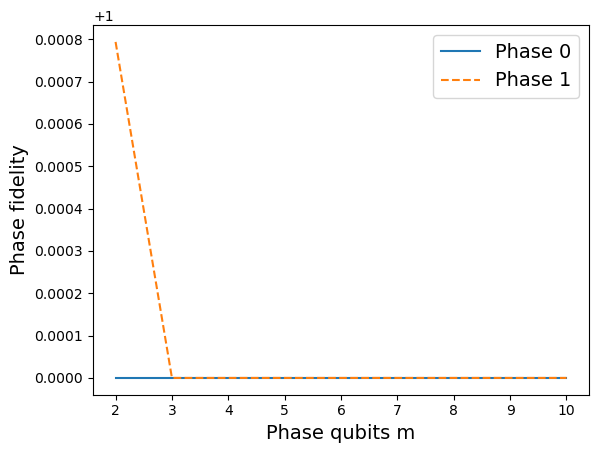

In [12]:
nMaxQubits = 10
nEigenValues = A.shape[0]
P0 = 0.1 # set this to 0 for simple weighted average
[D,V] = np.linalg.eig(A)
for eigenNum in range(nEigenValues):
	fidelity = []
	for m in range(2,nMaxQubits+1):
		v = V[:,eigenNum]
		thetak = D[eigenNum]/lambdaUpper
		[thetaEstimates,P] = myQPEMultiBit(A,v,lambdaUpper,m)	# type: ignore
		P [P <P0] = 0
		thetaTilde = np.sum(thetaEstimates*P)/np.sum(P)
		fidelity.append(thetaTilde/thetak)
	plt.plot(range(2,nMaxQubits+1), fidelity, next(linecycler))
plt.legend(['Phase 0','Phase 1','Phase 2','Phase 3'],fontsize = 14)
plt.xlabel('Phase qubits m',fontsize = 14);
plt.ylabel('Phase fidelity',fontsize = 14);
